In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

sns.set_style("darkgrid")

In [4]:
movies = pd.read_csv("../data/raw/ml-latest-small/movies.csv")
ratings = pd.read_csv("../data/raw/ml-latest-small/ratings.csv")
tags = pd.read_csv("../data/raw/ml-latest-small/tags.csv")
links = pd.read_csv("../data/raw/ml-latest-small/links.csv")

In [5]:
print("Movies:", movies.shape)
print("Ratings:", ratings.shape)
print("Tags:", tags.shape)
print("Links:", links.shape)

Movies: (9742, 3)
Ratings: (100836, 4)
Tags: (3683, 4)
Links: (9742, 3)


In [6]:
movies.head()
movies.info()
movies.describe(include="all")

<class 'pandas.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   movieId  9742 non-null   int64
 1   title    9742 non-null   str  
 2   genres   9742 non-null   str  
dtypes: int64(1), str(2)
memory usage: 626.1 KB


,movieId,title,genres
count,9742.000000,9742,9742
unique,NaN,9737,951
top,NaN,Emma (1996),Drama
freq,NaN,2,1053
mean,42200.353623,NaN,NaN
std,52160.494854,NaN,NaN
min,1.000000,NaN,NaN
25%,3248.250000,NaN,NaN
50%,7300.000000,NaN,NaN
75%,76232.000000,NaN,NaN


In [7]:
ratings.head()
ratings.info()
ratings.describe()

<class 'pandas.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB


,userId,movieId,rating,timestamp
count,100836.000000,100836.000000,100836.000000,1.008360e+05
mean,326.127564,19435.295718,3.501557,1.205946e+09
std,182.618491,35530.987199,1.042529,2.162610e+08
min,1.000000,1.000000,0.500000,8.281246e+08
25%,177.000000,1199.000000,3.000000,1.019124e+09
50%,325.000000,2991.000000,3.500000,1.186087e+09
75%,477.000000,8122.000000,4.000000,1.435994e+09
max,610.000000,193609.000000,5.000000,1.537799e+09


In [8]:
tags.head()

,userId,movieId,tag,timestamp
0,2,60756,funny,1445714994
1,2,60756,Highly quotable,1445714996
2,2,60756,will ferrell,1445714992
3,2,89774,Boxing story,1445715207
4,2,89774,MMA,1445715200


In [9]:
links.head()

,movieId,imdbId,tmdbId
0,1,114709,862.0
1,2,113497,8844.0
2,3,113228,15602.0
3,4,114885,31357.0
4,5,113041,11862.0


In [10]:
movies.isnull().sum()
ratings.isnull().sum()
tags.isnull().sum()
links.isnull().sum()

movieId    0
imdbId     0
tmdbId     8
dtype: int64

In [20]:
movies["movieId"].nunique()

9742

In [17]:
ratings["userId"].nunique()

610

In [18]:
ratings.shape[0]

100836

In [19]:
ratings.groupby("userId").size().mean()

np.float64(165.30491803278687)

In [21]:
ratings.groupby("movieId").size().mean()

np.float64(10.369806663924312)

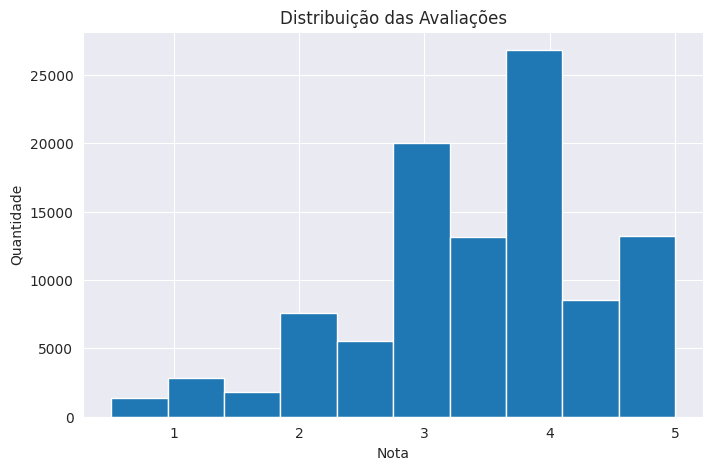

In [22]:
plt.figure(figsize=(8,5))

ratings["rating"].hist(bins=10)

plt.title("Distribuição das Avaliações")
plt.xlabel("Nota")
plt.ylabel("Quantidade")
plt.show()

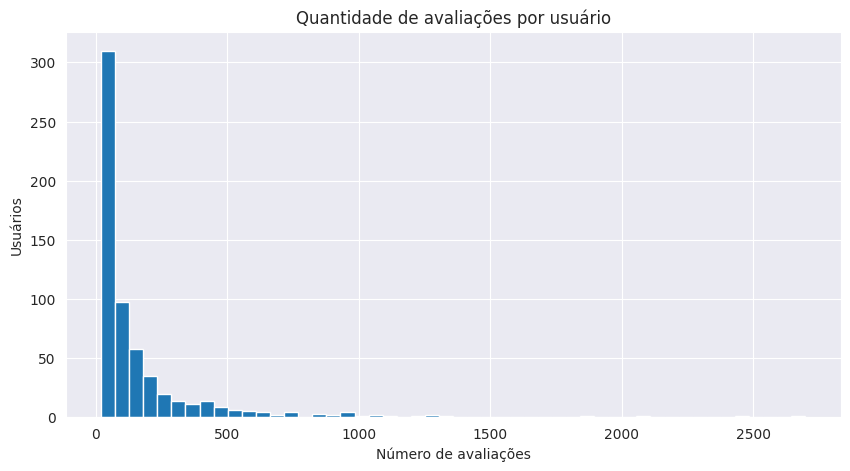

In [23]:
ratings_per_user = ratings.groupby("userId").size()

plt.figure(figsize=(10,5))

ratings_per_user.hist(bins=50)

plt.title("Quantidade de avaliações por usuário")
plt.xlabel("Número de avaliações")
plt.ylabel("Usuários")

plt.show()

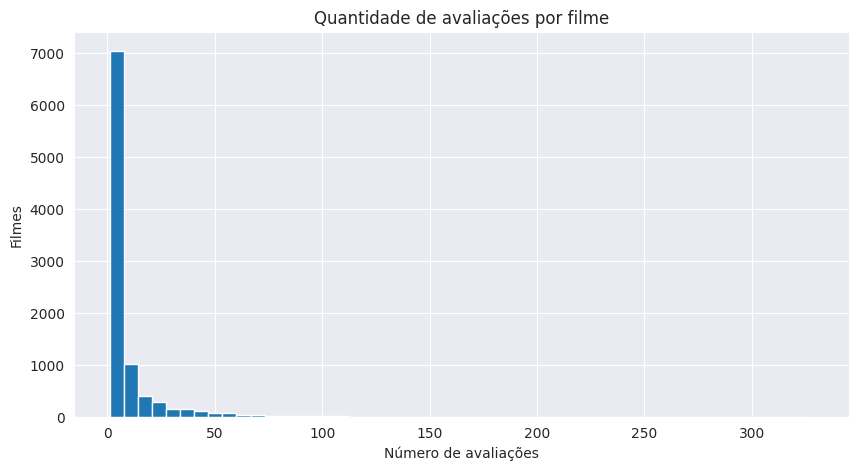

In [24]:
ratings_per_movie = ratings.groupby("movieId").size()

plt.figure(figsize=(10,5))

ratings_per_movie.hist(bins=50)

plt.title("Quantidade de avaliações por filme")
plt.xlabel("Número de avaliações")
plt.ylabel("Filmes")

plt.show()

In [25]:
top_movies = (
    ratings.groupby("movieId")
    .size()
    .sort_values(ascending=False)
    .head(10)
)

top_movies

movieId
356     329
318     317
296     307
593     279
2571    278
260     251
480     238
110     237
589     224
527     220
dtype: int64

In [26]:
top_movies = top_movies.reset_index(name="rating_count")

top_movies = top_movies.merge(
    movies,
    on="movieId"
)

top_movies[["title", "rating_count"]]

,title,rating_count
0,Forrest Gump (1994),329
1,"Shawshank Redemption, The (1994)",317
2,Pulp Fiction (1994),307
3,"Silence of the Lambs, The (1991)",279
4,"Matrix, The (1999)",278
5,Star Wars: Episode IV - A New Hope (1977),251
6,Jurassic Park (1993),238
7,Braveheart (1995),237
8,Terminator 2: Judgment Day (1991),224
9,Schindler's List (1993),220


In [27]:
genres = (
    movies["genres"]
    .str.split("|")
    .explode()
)

genre_counts = genres.value_counts()

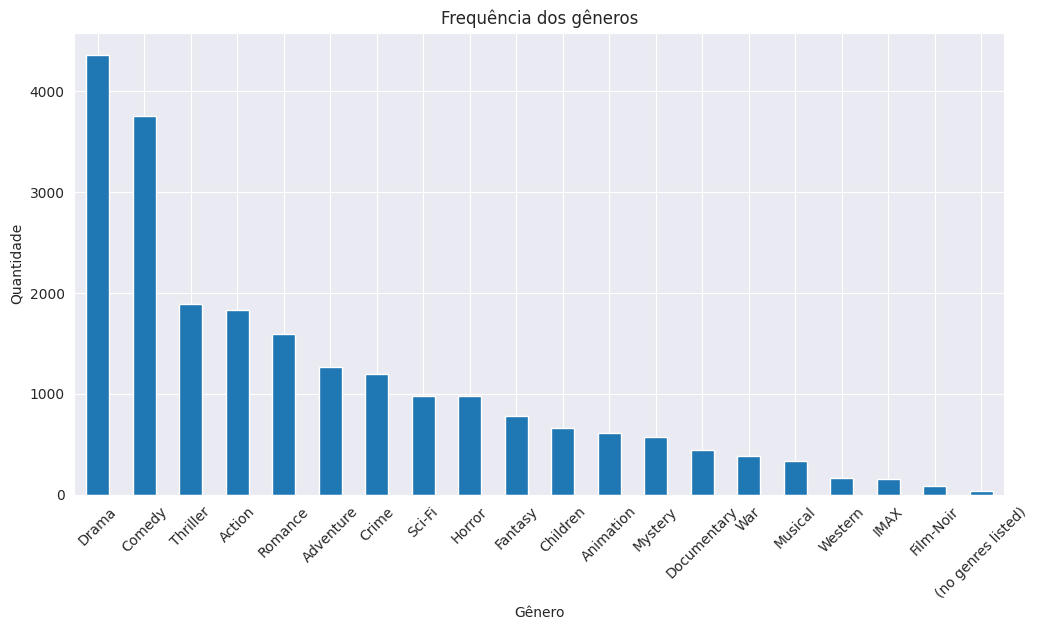

In [28]:
plt.figure(figsize=(12,6))

genre_counts.plot(kind="bar")

plt.title("Frequência dos gêneros")
plt.xlabel("Gênero")
plt.ylabel("Quantidade")

plt.xticks(rotation=45)

plt.show()

In [29]:
n_users = ratings["userId"].nunique()
n_movies = ratings["movieId"].nunique()

possible_interactions = n_users * n_movies

actual_interactions = ratings.shape[0]

sparsity = 1 - (actual_interactions / possible_interactions)

print(f"Sparsity: {sparsity:.4f}")

Sparsity: 0.9830
